<a href="https://colab.research.google.com/github/mannatdhull124/Time-Series-Forecasting-of-Air-Passengers/blob/main/Time_Series_Forecasting_of_Air_Passengers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AirPassenger**

###**Problem Statement**
We need to predict future airline passenger numbers using past data. The dataset has yearly data with the number of passengers recorded over time. Since the data shows trends and seasonal patterns, we use ARIMA and SARIMAX models to make accurate forecasts. These models help in planning and decision-making for airlines.

Dataset link: https://drive.google.com/file/d/1DZO2Mzu4wtSUOmTj3B-sVy8ZqyXbtiF_/view?usp=sharing

**Import Libraries**

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
from google.colab import files
uploaded = files.upload()

Saving AirPassengers.csv to AirPassengers.csv


**Configuration library**

In [11]:
import warnings
warnings.filterwarnings('ignore')

**Read the data**

In [12]:
df = pd.read_csv('/content/AirPassengers.csv')

In [13]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [14]:
df.tail()

,Month,#Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [15]:
df.isnull().sum()
# in the case we have null value, then don't drop, perform mean imputation

,0
Month,0
#Passengers,0


In [16]:
df.duplicated().sum()

np.int64(0)

**Data inspection**

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


**Insight**
* Month column is in object format

In [18]:
df['Month'] = pd.to_datetime(df['Month'])

In [19]:
df.head()

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [21]:
df.set_index("Month", inplace=True)
# df = df.set_index("Month") It does the same thing as above

In [22]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [23]:
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


###**Components of Time Series**

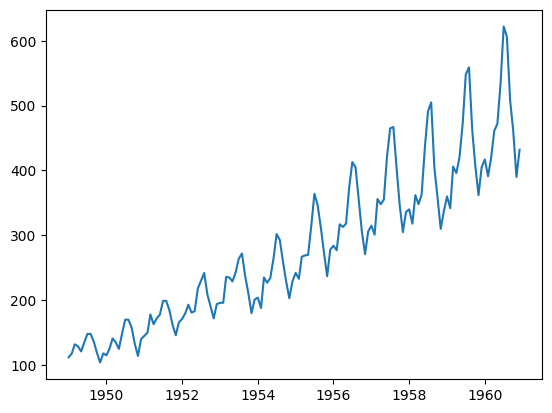

In [24]:
plt.plot(df['#Passengers'])
plt.show()

1. **Trend**: The upward movement from left to right that indicates clear increasing trend.
2. **Seasonality**: The repeating waves tells that we have a strong seasonality
3. **Residuals**: The random fluctuations that remain after accounting for trends and seasonlaity

In [25]:
# Yes we do have trend
# yes we do have seasonality
# yes we do have residuals

**Seasonal decompose is used to check the presence of the components**

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [27]:
decompose = seasonal_decompose(df['#Passengers'])

Figure(640x480)


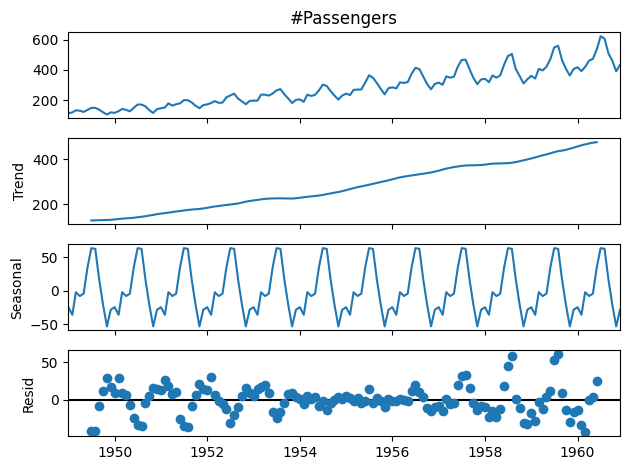

In [28]:
print(decompose.plot())

**Let's Check whether our data is stationary or not**

Here we are going to use ADF test (Augumented - Dickey - Fuller Test) -> Used to check if a time series is stationary or not.

###**Why stationary data is important?**
For many time models like ARIMA, the data needs to be stationary:
* Constant mean over time
* Constant variance over time
* No strong seasonality or trends

Non-stationary data can lead to poor forecasting performance because model may struggle to capture trends ans seasonality properly

In [29]:
from statsmodels.tsa.stattools import adfuller

* **Null hypothesis** - Data is not stationary
* **Alternate Hypothesis** - Data is stationary

In [30]:
result = adfuller(df['#Passengers'])
result

(np.float64(0.8153688792060498),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

1. ADF stats -> if it's less than my critical value -> stationary
2. pValue -> if > 0.05 -> data is non-stationary
3. lag: the number of past values considered in this test
4. Observation used: Data points used after removing lags
5. Critical values: at threshold of 1% , 5% and 10%
6. AIC -> tells you the best lag length to check

In [31]:
p_value = result[1]
p_value

np.float64(0.991880243437641)

In [32]:
if p_value <= 0.05:
  print('Null hypothesis is rejected thus data is stationary')
else:
  print('Null Hypothesis is accepted, thus data is non stationary')

Null Hypothesis is accepted, thus data is non stationary


In [33]:
rolling_mean = df.rolling(window=12).mean()

In [34]:









rolling_std = df.rolling(window=12).std()

In [35]:
rolling_mean.isnull().sum() # window size - 1

,0
#Passengers,11


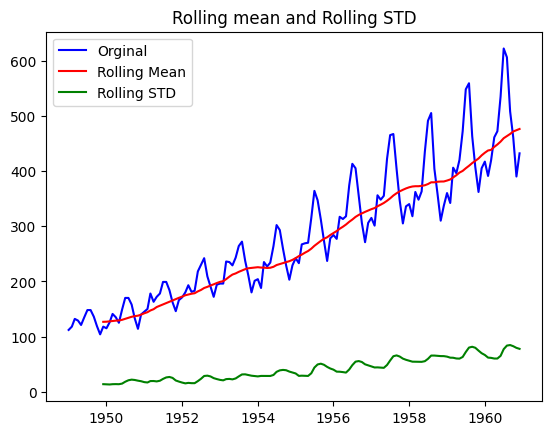

In [36]:
plt.plot(df,color = 'blue',label = 'Orginal')
plt.plot(rolling_mean , color = 'red',label = 'Rolling Mean')
plt.plot(rolling_std , color = 'green', label = 'Rolling STD')
plt.legend(loc='best')
plt.title('Rolling mean and Rolling STD')
plt.show()

**Since my data doesn't look stationary we can perform log Transformation**

###**log Transformation**
* It Compresses large values more than small ones, which reduce the gap between the large data.
* This makes big jumps in data less extreme, which can stablize variance

In [37]:
log_df = np.log(df)

In [38]:
log_df

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


In [39]:
rolling_mean = log_df.rolling(window=12).mean()
rolling_std = log_df.rolling(window = 12).std()

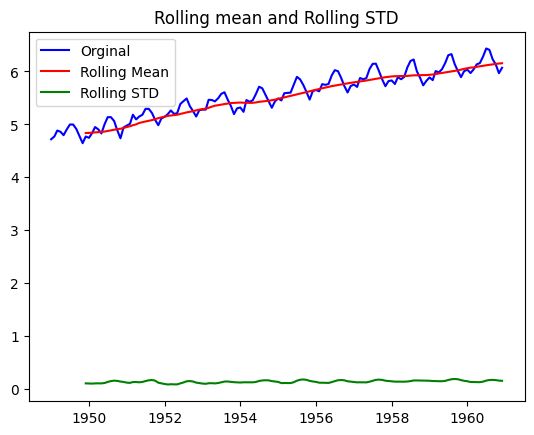

In [40]:
plt.plot(log_df,color = 'blue',label = 'Orginal')
plt.plot(rolling_mean , color = 'red',label = 'Rolling Mean')
plt.plot(rolling_std , color = 'green', label = 'Rolling STD')
plt.legend(loc='best')
plt.title('Rolling mean and Rolling STD')
plt.show()

**Now still after transforming we can see the data is not stationary, both values are not much constant (specifically mean)**

###**Differencing**
Diff = current value - previous value
* differencing removes the trend because we are focussing on the change between values rather than the value themselves
* if the tren was upward, the differencing would be more stable around a constant value

In [41]:
# let's perform differencing 1 time
diff_data = log_df.diff()
diff_data

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,0.052186
1949-03-01,0.112117
1949-04-01,-0.022990
1949-05-01,-0.064022
...,...
1960-08-01,-0.026060
1960-09-01,-0.176399
1960-10-01,-0.097083


In [42]:
diff_data.dropna(inplace=True)

In [43]:
diff_data

,#Passengers
Month,
1949-02-01,0.052186
1949-03-01,0.112117
1949-04-01,-0.022990
1949-05-01,-0.064022
1949-06-01,0.109484
...,...
1960-08-01,-0.026060
1960-09-01,-0.176399
1960-10-01,-0.097083


In [44]:
rolling_mean = diff_data.rolling(window=12).mean()
rolling_std = diff_data.rolling(window=12).std()

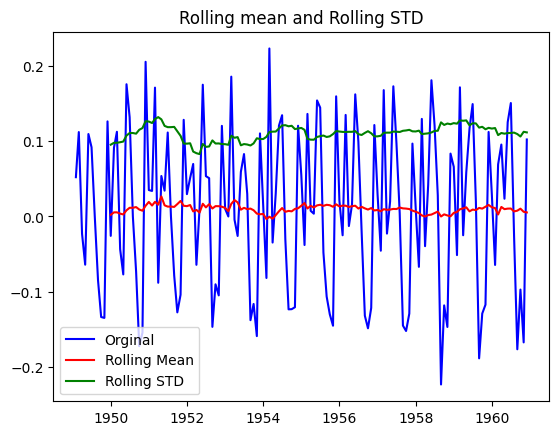

In [45]:
plt.plot(diff_data,color = 'blue',label = 'Orginal')
plt.plot(rolling_mean , color = 'red',label = 'Rolling Mean')
plt.plot(rolling_std , color = 'green', label = 'Rolling STD')
plt.legend(loc='best')
plt.title('Rolling mean and Rolling STD')
plt.show()

In [46]:
result = adfuller(diff_data['#Passengers'])
result

(np.float64(-2.717130598388114),
 np.float64(0.07112054815086184),
 14,
 128,
 {'1%': np.float64(-3.4825006939887997),
  '5%': np.float64(-2.884397984161377),
  '10%': np.float64(-2.578960197753906)},
 np.float64(-440.35846985568105))

In [47]:
if p_value <= 0.05:
  print('Null hypothesis is rejected thus data is stationary')
else:
  print('Null Hypothesis is accepted, thus data is non stationary')

Null Hypothesis is accepted, thus data is non stationary


**Let's consider the above data as stationary as we don't have much data to loose**
* since we are getting the marginal p value, we can take it

**To implement shift**

In [48]:
diff_data = diff_data.shift(-1)

In [49]:
diff_data

,#Passengers
Month,
1949-02-01,0.112117
1949-03-01,-0.022990
1949-04-01,-0.064022
1949-05-01,0.109484
1949-06-01,0.091937
...,...
1960-08-01,-0.176399
1960-09-01,-0.097083
1960-10-01,-0.167251


In [50]:
diff_data.dropna(inplace=True)

In [51]:
result = adfuller(diff_data)
p_value = result[1]

In [52]:
p_value

np.float64(0.048033972528754854)

In [53]:
if p_value <= 0.05:
  print('Null hypothesis is rejected thus data is stationary')
else:
  print('Null Hypothesis is accepted, thus data is non stationary')

Null hypothesis is rejected thus data is stationary


In [54]:
# (pdq) p - Auto Regression (AR), D is differcing d  = 1 , Q Moving average(Q = 1)

**For model building we will use log_df data because we know d = 1 we have to give**

In [55]:
log_df

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


**Let's split the data into training and testing**

In [56]:
train = log_df.iloc[:120, :] # 10 year of data
test = log_df.iloc[120:,:] # 2 year data

In [57]:

train

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1958-08-01,6.224558
1958-09-01,6.001415
1958-10-01,5.883322


In [58]:
test

,#Passengers
Month,
1959-01-01,5.886104
1959-02-01,5.834811
1959-03-01,6.006353
1959-04-01,5.981414
1959-05-01,6.040255
1959-06-01,6.156979
1959-07-01,6.306275
1959-08-01,6.326149
1959-09-01,6.137727


###**ARIMA - Auto Regressive Integrated Moving Average**

* P - How much of the past data you add (AR)
* D - How much trend you want to remove (Differencing)
* Q - How much you correct yourself from mistakes (Moving Average)

In [59]:


from statsmodels.tsa.arima.model import ARIMA

In [60]:
model = ARIMA(train,order = (1,1,2)) # order of arima (p =?, d= 1,q= ?) # let's take random order

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [61]:

model = model.fit()

In [62]:
len(train)

120

In [63]:
len

<function len(obj, /)>

In [64]:
len(train) + len(test)-1

143

In [65]:
log_df['Arima_prediction'] = model.predict(start = len(train), end = len(train) + len(test)-1)

In [66]:
log_df

,#Passengers,Arima_prediction
Month,,
1949-01-01,4.718499,NaN
1949-02-01,4.770685,NaN
1949-03-01,4.882802,NaN
1949-04-01,4.859812,NaN
1949-05-01,4.795791,NaN
...,...,...
1960-08-01,6.406880,5.912387
1960-09-01,6.230481,5.912387
1960-10-01,6.133398,5.912387


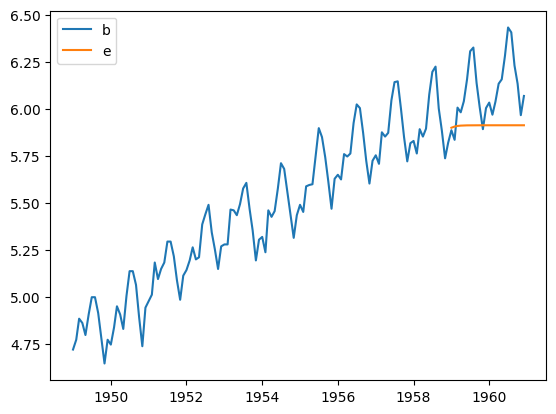

In [67]:
plt.plot(log_df)
plt.legend('best')
plt.show()

We are not getting good prediction as we used pdq value which random

In [68]:


# we will use here itertools to get the optimal value of p,d,q
import itertools

p = range(1,8)
d = range(1,2)
q = range(1,8)

pdq_combinations = list(itertools.product(p,d,q)) # product method will do cartesian prodcut
pdq_combinations

[(1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (1, 1, 4),
 (1, 1, 5),
 (1, 1, 6),
 (1, 1, 7),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (2, 1, 4),
 (2, 1, 5),
 (2, 1, 6),
 (2, 1, 7),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3),
 (3, 1, 4),
 (3, 1, 5),
 (3, 1, 6),
 (3, 1, 7),
 (4, 1, 1),
 (4, 1, 2),
 (4, 1, 3),
 (4, 1, 4),
 (4, 1, 5),
 (4, 1, 6),
 (4, 1, 7),
 (5, 1, 1),
 (5, 1, 2),
 (5, 1, 3),
 (5, 1, 4),
 (5, 1, 5),
 (5, 1, 6),
 (5, 1, 7),
 (6, 1, 1),
 (6, 1, 2),
 (6, 1, 3),
 (6, 1, 4),
 (6, 1, 5),
 (6, 1, 6),
 (6, 1, 7),
 (7, 1, 1),
 (7, 1, 2),
 (7, 1, 3),
 (7, 1, 4),
 (7, 1, 5),
 (7, 1, 6),
 (7, 1, 7)]

In [69]:
len(pdq_combinations)

49

In [70]:




from sklearn.metrics import mean_squared_error

In [71]:
rmse = []
order1 = []
for pdq in pdq_combinations:
  model = ARIMA(train,order = pdq)
  model_fit = model.fit()
  pred = model_fit.predict(start = len(train),end =len(train) + len(test)-1)
  error = np.sqrt(mean_squared_error(test,pred))
  order1.append(pdq)
  rmse.append(error)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

In [72]:
results = pd.DataFrame(index=order1, data=rmse, columns=['RMSE'])

In [73]:
results.sort_values(by='RMSE',ascending=True)

,RMSE
"(5, 1, 4)",0.155013
"(6, 1, 4)",0.158187
"(7, 1, 7)",0.165622
"(7, 1, 5)",0.171635
"(7, 1, 4)",0.176668
"(6, 1, 5)",0.182591
"(7, 1, 2)",0.189217
"(7, 1, 3)",0.189703
"(5, 1, 5)",0.189813
"(1, 1, 5)",0.193841



**From the above code we found the best parameter for PDQ = (5,1,4)**

In [74]:


model = ARIMA(train,order=(5,1,4))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [75]:




model = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [76]:

log_df['Arima_prediction'] = model.predict(start = len(train),end =len(train) + len(test)-1)

In [77]:
log_df

,#Passengers,Arima_prediction
Month,,
1949-01-01,4.718499,NaN
1949-02-01,4.770685,NaN
1949-03-01,4.882802,NaN
1949-04-01,4.859812,NaN
1949-05-01,4.795791,NaN
...,...,...
1960-08-01,6.406880,6.073565
1960-09-01,6.230481,6.016085
1960-10-01,6.133398,5.930742


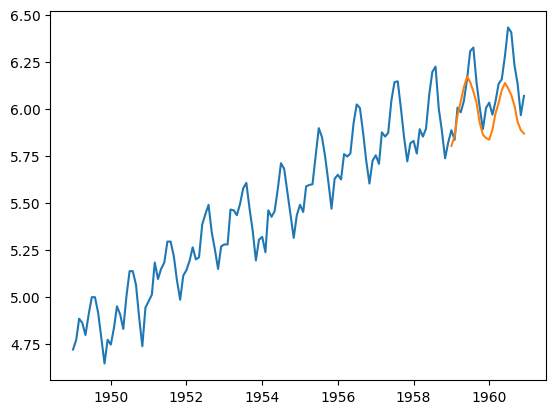

In [78]:
plt.plot(log_df)
plt.show()

* Yellow plot is showing prediction
* blue plot is your actual data

In [79]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [80]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [81]:
df.tail()

,#Passengers
Month,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


In [82]:
s_model = SARIMAX(train,order = (5,1,4),seasonal_order=(5,1,4,12)) # (p,d,q,s) # seasonality = 12 (yearly data)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [83]:
s_model = s_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [84]:
log_df['Sarima_prediction'] = s_model.predict(start = len(train),end =len(train) + len(test)-1)

In [85]:
log_df

,#Passengers,Arima_prediction,Sarima_prediction
Month,,,
1949-01-01,4.718499,NaN,NaN
1949-02-01,4.770685,NaN,NaN
1949-03-01,4.882802,NaN,NaN
1949-04-01,4.859812,NaN,NaN
1949-05-01,4.795791,NaN,NaN
...,...,...,...
1960-08-01,6.406880,6.073565,6.338585
1960-09-01,6.230481,6.016085,6.165951
1960-10-01,6.133398,5.930742,6.034450


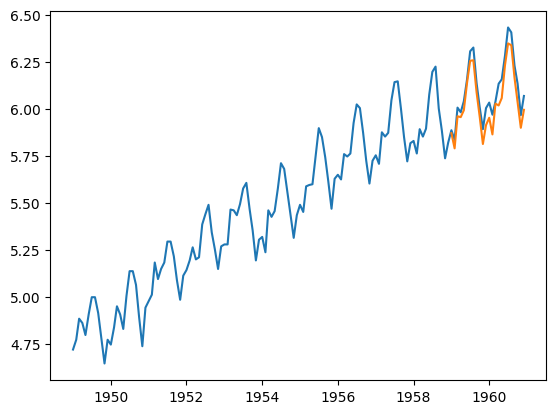

In [86]:
plt.plot(log_df['#Passengers'])
plt.plot(log_df['Sarima_prediction'])
plt.show()

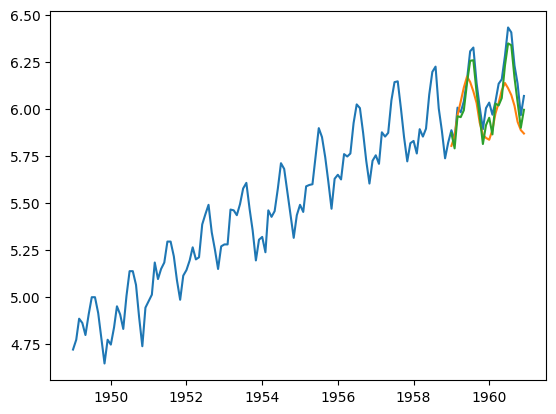

In [87]:
plt.plot(log_df)

###**Forecasting**

In [88]:
future = s_model.forecast(steps = 60) # next 5 years

In [89]:
future

,predicted_mean
1959-01-01,5.870420
1959-02-01,5.789432
1959-03-01,5.960329
1959-04-01,5.955760
1959-05-01,5.992145
1959-06-01,6.138351
1959-07-01,6.255467
1959-08-01,6.258533
1959-09-01,6.087687
1959-10-01,5.958353


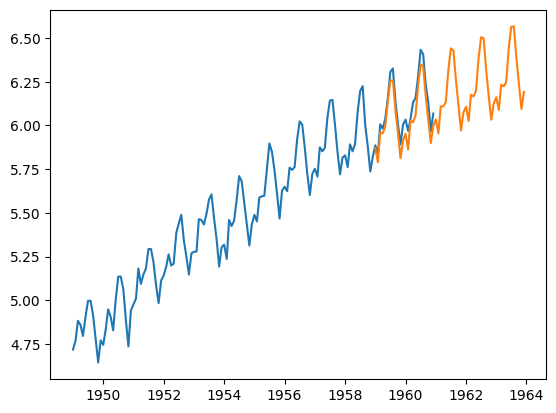

In [90]:
plt.plot(log_df['#Passengers'])
plt.plot(future)
plt.show()

In [91]:
future

,predicted_mean
1959-01-01,5.870420
1959-02-01,5.789432
1959-03-01,5.960329
1959-04-01,5.955760
1959-05-01,5.992145
1959-06-01,6.138351
1959-07-01,6.255467
1959-08-01,6.258533
1959-09-01,6.087687
1959-10-01,5.958353


**Reverse of log is Exponential**

In [92]:
round(np.exp(6.258278))

522

In [93]:
round(np.exp(future)) # Actual value of passengers travel in future

,predicted_mean
1959-01-01,354.0
1959-02-01,327.0
1959-03-01,388.0
1959-04-01,386.0
1959-05-01,400.0
1959-06-01,463.0
1959-07-01,521.0
1959-08-01,522.0
1959-09-01,440.0
1959-10-01,387.0


The ARIMA model was able to capture the general trend in the passenger data but showed limitations in handling seasonality.

The SARIMA model provided better forecasting performance by considering both trend and seasonal patterns present in the dataset.

Visualization plots showed that SARIMA predictions were closer to the actual passenger values compared to ARIMA.

Future forecasting results indicated a continued increase in passenger counts over upcoming months, demonstrating the effectiveness of the SARIMA model for seasonal time series forecasting.